In [1]:
import cv2
import numpy as np

In [2]:
# Part I: A photo booth application 
empty_image = np.ones((400, 400, 3), dtype=np.uint8) * 255


# red circle
cv2.circle(empty_image, (200,75), 70, (0,0,255), thickness=-1) 
cv2.circle(empty_image, (200,75), 30, (255,255,255), thickness=-1)

# green circle
cv2.circle(empty_image, (125,205), 70, (0,255,0), thickness=-1)
cv2.circle(empty_image, (125,205), 30, (255,255,255), thickness=-1)

# blue circle
cv2.circle(empty_image, (275,205), 70, (255,0,0), thickness=-1)
cv2.circle(empty_image, (275,205), 30, (255,255,255), thickness=-1)

# white triangle 
triangle = np.array([[200,75],[125,205],[275,205]], np.int32)
triangle = triangle.reshape(3,1,2)
cv2.fillPoly(empty_image,[triangle],color=(255,255,255))

# blue circle re-draw
cv2.circle(empty_image, (275,205), 70, (255,0,0), thickness=-1)
cv2.circle(empty_image, (275,205), 30, (255,255,255), thickness=-1)
cv2.ellipse(empty_image, center=(275,205), axes=(70, 70), angle=0, startAngle=240,endAngle=300, color=(255,255,255), thickness=-1)

# OpenCV
cv2.putText(empty_image,'OpenCV',(125,325), cv2.FONT_HERSHEY_SIMPLEX, 1.25 , (0,0,0),4)

cv2.imshow('PART I: A photo booth application', empty_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
# Part II: Image Arithmetic 
import cv2
import numpy as np

img1 = cv2.imread("123.jpg")
img2 = cv2.imread("airlineAnalysis.jpg")

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

cv2.imshow('test1', img1)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imshow('test2', img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

a = 0.5

blend = np.uint8((1 - a) * img1 + a * img2)



cv2.imshow("manual_blend.jpg", blend)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite("manual_blend.jpg", blend)


True

==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation
8. View History of Operations
9. Save and Exit
Padding size changed to square and border type is constant


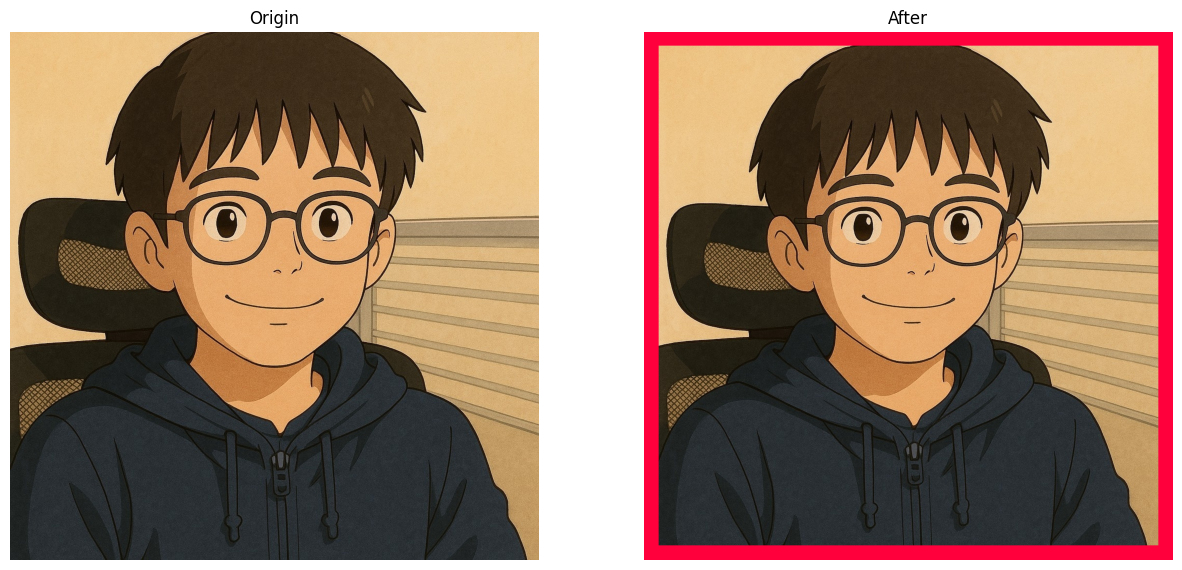

==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation
8. View History of Operations
9. Save and Exit
History log
1. Original image loaded
2. Padding size changed to square and border type is constant
==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation
8. View History of Operations
9. Save and Exit
History log
1. Original image loaded
2. Padding size changed to square and border type is constant
==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:836: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'cv::imwrite_'


In [2]:
# PART III: Image Arithmetic
import cv2
import numpy as np
import matplotlib.pyplot as plt

def menu():
    print("==== Mini Photo Editor ====")
    print("1. Adjust Brightness")
    print("2. Adjust Contrast")
    print("3. Convert to Grayscale")
    print("4. Add Padding (choose border type)")
    print("5. Apply Thresholding (binary or inverse)")
    print("6. Blend with Another Image (manual alpha)")
    print("7. Undo Last Operation")
    print("8. View History of Operations")
    print("9. Save and Exit")


def show_side_by_side(origin, after):
    plt.figure(figsize=(15,10))
    plt.subplot(1,2,1)
    plt.title("Origin")
    plt.axis('off')
    plt.imshow(cv2.cvtColor(origin, cv2.COLOR_BGR2RGB))
    plt.subplot(1,2,2)
    plt.title("After")
    plt.axis('off')
    plt.imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
    plt.show()


# Brightness
def adjust_brightness(img):
    origin = img.copy()
    input_brightness = input("Please input the number you want to adjust for brightness:")
    if not input_brightness.lstrip('-').isdigit():
        print("Invalid number.")
        return img
    input_brightness = int(input_brightness)
    if input_brightness > 0:
        img = cv2.add(img, np.ones(img.shape, dtype=np.uint8) * input_brightness)
    elif input_brightness < 0:
        img = cv2.subtract(img, np.ones(img.shape, dtype=np.uint8) * abs(input_brightness))
    else:
        print("No change because you type 0. No compared img shown and back to menu.")
        return img
    history_save(img, f"Brightness adjusted by {input_brightness}")
    print(f"Brightness adjusted by {input_brightness}")
    show_side_by_side(origin, img)
    return img


# Contrast
def adjust_contrast(img):
    origin = img.copy()
    input_contrast = input("Please input the number you want to adjust for contrast: (decimal, e.g. 0.0, 1.5, 2.0...)")
    try:
        alpha = float(input_contrast)
    except:
        print("Invalid number. No compared img shown and back to menu.")
        return img
    contrast_img = cv2.convertScaleAbs(img, alpha=alpha, beta=0)
    img = contrast_img
    history_save(img, f"Contrast change by {input_contrast}")
    print(f"Contrast change by {input_contrast}")
    show_side_by_side(origin, img)
    return img


# Grayscale
def convert_to_grayscale(img):
    origin = img.copy()
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img_gray
    history_save(img, "Gray image changed.")
    print("Gray image changed.")
    show_side_by_side(origin, img)
    return img

# Padding
def add_padding(img):
    origin = img.copy()
    input_padding = input("Padding border size(square, rectangle, custom ratio)")
    top = bottom = left = right = 0
    if input_padding == "square":
        # Ask the user for padding size
        padding_size = int(input("Enter the padding size to be added on each side: "))
        max_side = max(img.shape[0], img.shape[1]) # find the longer side, height or width
        top = bottom = ((max_side - img.shape[0]) // 2) + padding_size # if top and bottom is shorter, padding should be added, and split evenly to the padding, force add 50 for padding 
        left = right = ((max_side - img.shape[1]) // 2) + padding_size # if left and right is shorter, padding should be added, and split evenly to the padding, force add 50 for padding 
    elif input_padding == 'rectangle':
        top = bottom = 50
        left = right = 50
    elif input_padding == 'custom ratio':
        input_ratio = input("Please the ratio(e.g. 4:5): ")
        if ':' not in input_ratio:
            print("Invalid format, you must have column symbol.")
            return img
        ratio_parts = input_ratio.split(":")
        first_part = int(ratio_parts[0])
        second_part = int(ratio_parts[1])
        current_height, current_weight = img.shape[:2]
        current_img_ratio = current_height / current_weight
        target_img_ratio = first_part / second_part
        
        # need padding to left and right
        if current_img_ratio < target_img_ratio:
            target_width = int(current_height * target_img_ratio)
            pad_total = target_width - current_weight
            left = right = pad_total // 2
            top = bottom = 0
        # need padding to top and bottom
        elif current_img_ratio > target_img_ratio:
            target_height = int(current_weight / target_img_ratio)
            pad_total = target_height - current_height
            top = bottom = pad_total // 2
            left = right = 0
        else:
            top = bottom = left = right = 0

        # The user should also be able to adjust the total padding size, and your code must maintain the proportion 
        # accordingly. (add smallest padding at the beginning to make it rectangle, then increase or 
        # decrease the padding size of the user wants) 
        add_morePadding = input("Do you need extra padding(y/n)?: ")
        if add_morePadding == 'y':
            extra_padding = int(input("Please input the total extra padding size: "))
            total_ratio = first_part + second_part
            extra_height = int(extra_padding * (first_part / total_ratio))
            extra_weight = int(extra_padding * (second_part / total_ratio))

            # Make sure top, bottom and left, right sum will be total
            top += extra_height // 2
            bottom = extra_height - (extra_height // 2)
            left += extra_weight // 2
            right += extra_weight - (extra_weight // 2)

    else:
        print("Invalid option")
        return img

    borderType_check = True
    while borderType_check:
        input_borderType = input("Please input the border type: (constant, reflect, replicate)")
        if input_borderType == 'constant':
            input_color = input("Please input the color by B G R from 0 to 255(e.g. 255,255,255), otherwise will be default color(Black)")
            color = [0,0,0]

            if input_color != "":
                parts = input_color.split(',')
                if len(parts) == 3 and all(p.strip().isdigit() for p in parts):
                    r, g, b = map(int, map(str.strip, parts))
                    if all(0 <= x <= 255 for x in [r, g, b]):
                        color = [b, g, r]
                else:
                    print("Color values must be between 0 and 255. Using default black.")
            else:
                print("Invalid format. Using default black.")
            borderType = cv2.BORDER_CONSTANT
            borderType_check = False
        elif input_borderType == 'reflect':
            borderType = cv2.BORDER_REFLECT
            borderType_check = False
        elif input_borderType == 'replicate':
            borderType = cv2.BORDER_REPLICATE
            borderType_check = False
        else:
            print("Invalid border Type.")
            borderType_check = True

    if borderType == cv2.BORDER_CONSTANT:
        padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType, value=color) # update color, haven't test if it's correct
    else:
        padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType)
    img = padded_img
    # add history function here
    history_save(img, f"Padding size changed to {input_padding} and border type is {input_borderType}")
    print(f"Padding size changed to {input_padding} and border type is {input_borderType}")
    show_side_by_side(origin, img)
    return img

# Threshold
def add_threshold(img):
    origin = img.copy()
    input_mode = input("Choose mode (binary / binary_inv): ").strip()
    if input_mode == "binary":
        thresh_type = cv2.THRESH_BINARY
    elif input_mode == "binary_inv":
        thresh_type = cv2.THRESH_BINARY_INV
    else:
        print("Invalid mode.")
        return img
    if len(img.shape) == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray_img = img
    _, img = cv2.threshold(gray_img,127,255,thresh_type)
    history_save(img, f"Threshold applied with mode: {input_mode}")
    show_side_by_side(origin, img)
    return img
# Blend
def blend_image(img):
    origin = img.copy()
    path_check2 = True
    while path_check2:
        file_path2 = input("Please input your second image path(e.g. xxx.jpg, or C:/xxxx/xxx/image.jpg): ")
        img2 = cv2.imread(file_path2)
        if img2 is None:
            print("No image or path is incorrect")
        else:
            path_check2 = False
    img2 = cv2.resize(img2, (img.shape[1], img.shape[0]))
    input_alpha = input("Please input alpha value from 0 to 1(e.g. 0.5): ")
    try:
        alpha = float(input_alpha)
    except:
        print("Invalid format.")
        return img
    img_blend = cv2.addWeighted(img, alpha, img2, alpha, gamma=0)
    img = img_blend
    history_save(img, f"{file_path2} of the second image has blended into img 1")
    print(f"{file_path2} of the second image has blended into first img")
    show_side_by_side(origin, img)
    return img


# Undo
def undo_last_operation(img):
    if len(history) > 1:
        history.pop()
        action = history_log.pop()
        img = history[-1].copy()
        print(f"Undo last operation: {action}")
    else:
        print("Undo failed. You're already back to origin image")
    return img

# View history
def view_history():
    if history_log:
        print("History log")
        for i, action in enumerate(history_log):
            print(f"{i+1}. {action}")
    else:
        print("No history")

# Save
def save_and_exit(img):
    output_img_name = input("Please enter the filename to save(e.g. xxx.png): ")
    cv2.imwrite(output_img_name, img)
    print(f"Image saved {output_img_name}. Good bye~")
    return True

# save image and history log
def history_save(img, log):
    history.append(img.copy())
    history_log.append(log)

#<------------------------------------- Main --------------------------------------------------->

# For implement 7 and 8
history = []
history_log = []

# Load first image
path_check = True
while path_check:
    file_path = input("Please input your image path(e.g. xxx.jpg, or C:/xxxx/xxx/image.jpg): ")
    img = cv2.imread(file_path)

    if img is None:
        print("No image or path is incorrect")
        path_check = True
    else:
        path_check = False
        history_save(img, "Original image loaded") # put the origin image and log into history 

# Call main function
menu_check = True
while menu_check:
    menu()
    input_option = input("Please select the feature (1-9): ")

    if not input_option.isdigit():
        print("Please enter a valid number.")
        continue

    input_option = int(input_option)

    match input_option:
        case 1:
            img = adjust_brightness(img)
        case 2:
            img = adjust_contrast(img)
        case 3:
            img = convert_to_grayscale(img)
        case 4:
            img = add_padding(img)
        case 5:
            img = add_threshold(img)
        case 6:
            img = blend_image(img) 
        case 7:
            img = undo_last_operation(img)
        case 8:
            view_history()
        case 9:
            save_and_exit(img)
            break

#<------------------------------------- End --------------------------------------------------->




                    
            



In [ ]:
#Part IV:
print("I, Hengmin Tsao, declare that I have read and understood the Academic Integrity Policy.")

I, Hengmin Tsao, declare that I have read and understood the Academic Integrity Policy.
